In [1]:
from google.colab import files
uploaded = files.upload()

Saving sales_dataset.csv to sales_dataset.csv


In [2]:
import pandas as pd
df = pd.read_csv("sales_dataset.csv")
df.head()

,Order_ID,Date,Customer_ID,Product,Category,Region,Sales,Quantity,Marketing_Spend
0,1001,2024-01-05,C001,Laptop,Electronics,North,55000,1,5000
1,1002,2024-01-07,C002,Phone,Electronics,South,30000,2,3000
2,1003,2024-01-10,C003,Tablet,Electronics,East,20000,1,2000
3,1004,2024-01-12,C004,Headphones,Accessories,West,2000,3,500
4,1005,2024-01-15,C005,Keyboard,Accessories,North,1500,2,300


In [3]:
df[['Sales','Quantity','Marketing_Spend']].describe()

,Sales,Quantity,Marketing_Spend
count,20.00000,20.000000,20.000000
mean,22950.00000,2.050000,2290.000000
std,21941.72905,1.190975,1958.288727
min,800.00000,1.000000,200.000000
25%,1675.00000,1.000000,387.500000
50%,21500.00000,2.000000,2150.000000
75%,32250.00000,2.250000,3225.000000
max,62000.00000,5.000000,6000.000000


In [4]:
df['Category'].value_counts()
df['Region'].value_counts()

,count
Region,
North,5
South,5
East,5
West,5


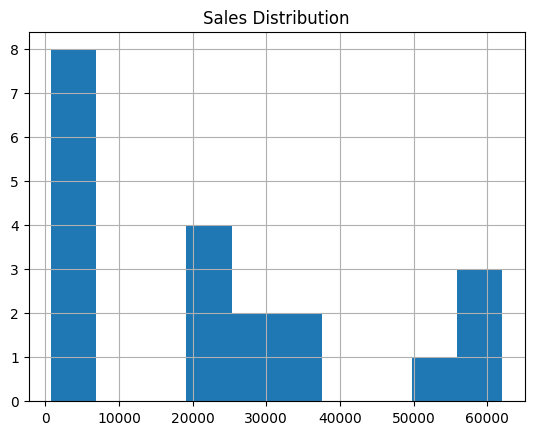

In [5]:
import matplotlib.pyplot as plt

df['Sales'].hist()
plt.title("Sales Distribution")
plt.show()

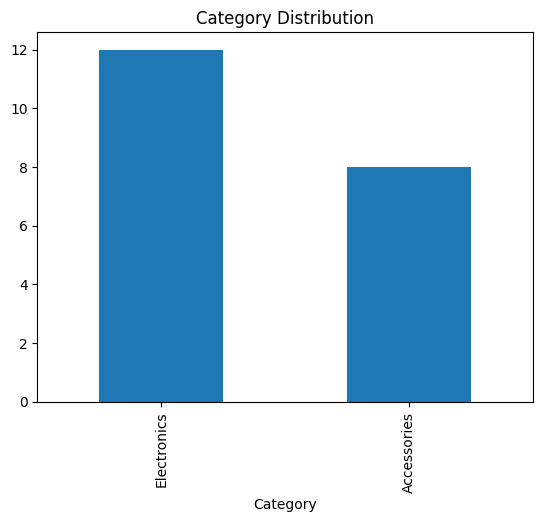

In [6]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Category Distribution")
plt.show()

In [7]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')

20

In [8]:
query = """
SELECT Product, SUM(Sales) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 5;
"""
pd.read_sql_query(query, conn)

,Product,Revenue
0,Laptop,235000
1,Phone,126000
2,Tablet,86000
3,Keyboard,4800
4,Headphones,4500


In [9]:
query = """
SELECT strftime('%Y-%m', Date) AS Month,
       SUM(Sales) AS Total_Sales
FROM sales
GROUP BY Month;
"""
pd.read_sql_query(query, conn)

,Month,Total_Sales
0,2024-01,108500
1,2024-02,115400
2,2024-03,114400
3,2024-04,120700


In [10]:
query = """
SELECT Category, SUM(Sales) AS Revenue
FROM sales
GROUP BY Category;
"""
pd.read_sql_query(query, conn)

,Category,Revenue
0,Accessories,12000
1,Electronics,447000


In [11]:
query="""
select Region,sum(Sales) as Revenue from sales Group by Region;
"""
pd.read_sql_query(query,conn)

,Region,Revenue
0,East,112600
1,North,112300
2,South,117100
3,West,117000


In [12]:
query="select avg(Sales) as Avg_Order_Value from sales;"
pd.read_sql_query(query,conn)

,Avg_Order_Value
0,22950.0


In [13]:
query="""
select Product ,sum(Quantity) as Total_Quantity from sales group by Product order by Total_Quantity DESC;
"""
pd.read_sql_query(query,conn)

,Product,Total_Quantity
0,Mouse,13
1,Phone,8
2,Keyboard,6
3,Headphones,6
4,Tablet,4
5,Laptop,4


In [14]:
query="""
select Product,sum(Sales)*1.0/sum(Marketing_Spend) as ROI from sales group by Product;
"""
pd.read_sql_query(query,conn)

,Product,ROI
0,Headphones,4.090909
1,Keyboard,4.571429
2,Laptop,10.829493
3,Mouse,3.600000
4,Phone,10.000000
5,Tablet,10.000000


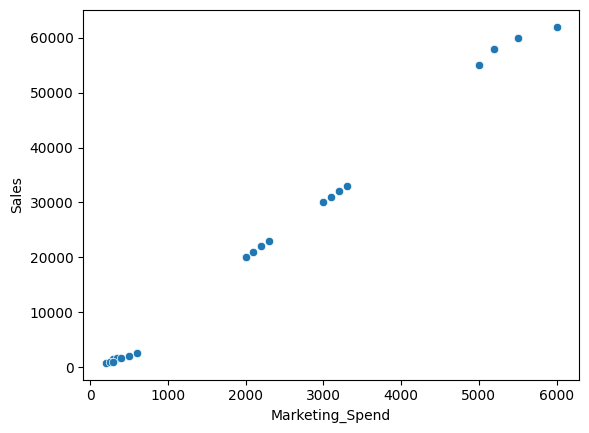

In [15]:
import seaborn as sns
sns.scatterplot(x='Marketing_Spend',y='Sales',data=df)
plt.show()

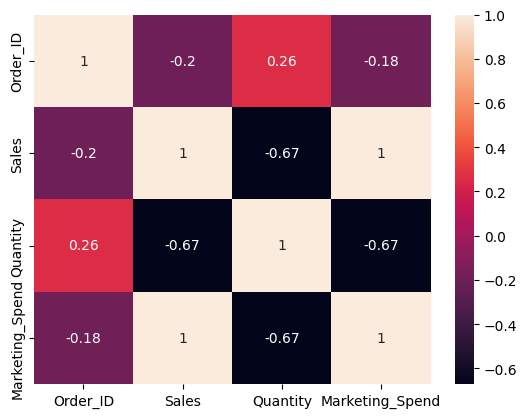

In [17]:
import matplotlib.pyplot as plt
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)
plt.show()

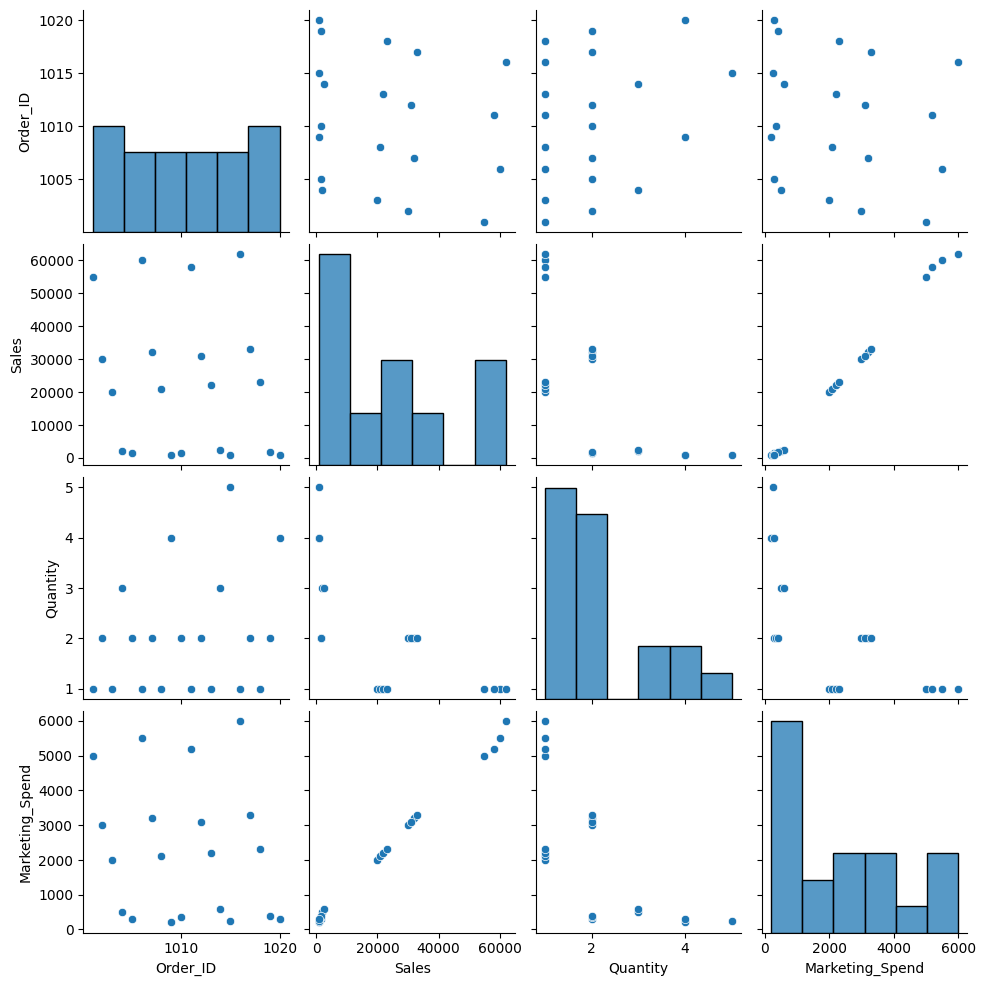

In [18]:
sns.pairplot(df)